Image size: 1153 x 1104 px


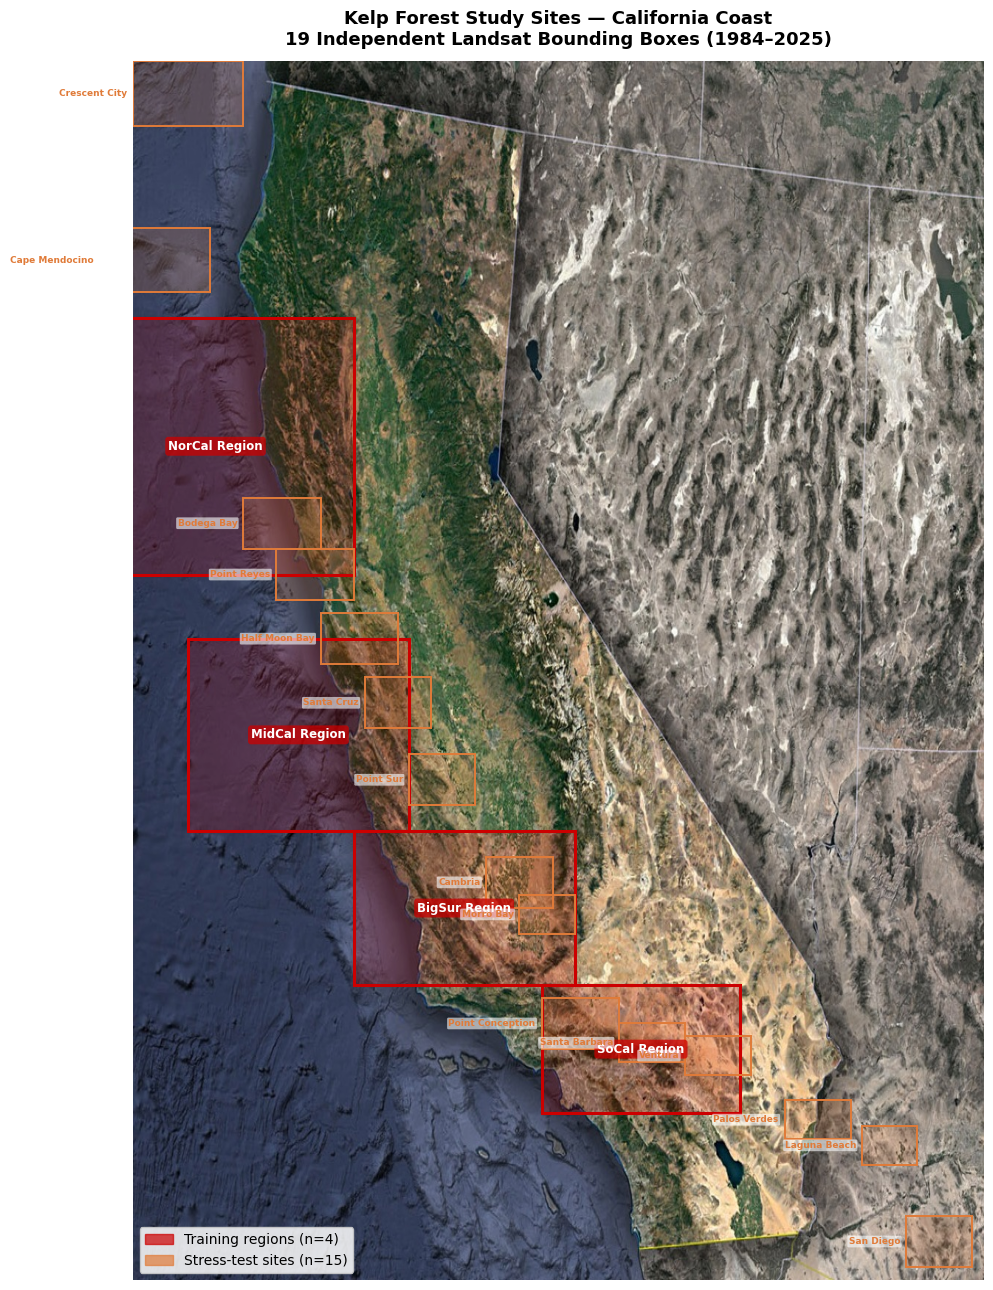

Saved: /Users/tonylin/Documents/kelp_project/5_FIGURES/supplementary/california_bbox_map.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from PIL import Image
from pathlib import Path

# ── Load image ───────────────────────────────────────────────
IMG_PATH = Path('/Users/tonylin/Documents/kelp_project/2_NOTEBOOKS/TESTS/california coast map.jpg')
img = np.array(Image.open(IMG_PATH))
img_h, img_w = img.shape[:2]
print(f'Image size: {img_w} x {img_h} px')

# ── Coordinate calibration ───────────────────────────────────
# Map geographic bounds to pixel bounds.
# Calibrated from known coastal landmarks visible in the image:
#   Oregon border (top of coast)  ~ 42.0N, 124.2W  → top-left of coastline
#   San Diego (bottom of coast)   ~ 32.5N, 117.1W  → bottom-right of coastline
# Linear transform: geo → pixel
LAT_MAX, LAT_MIN =  42.0, 32.5
LON_MIN, LON_MAX = -124.5, -116.8

def geo_to_px(lat, lon):
    """Convert lat/lon to pixel x, y."""
    x = (lon - LON_MIN) / (LON_MAX - LON_MIN) * img_w
    y = (LAT_MAX - lat) / (LAT_MAX - LAT_MIN) * img_h
    return x, y

# ── Bounding boxes ───────────────────────────────────────────
# (name, lat_lo, lat_hi, lon_lo, lon_hi, is_training)
BBOXES = [
    # 4 main training regions — RED
    ('NorCal Region',    38.0, 40.0, -125.0, -122.5,  True),
    ('MidCal Region',    36.0, 37.5, -124.0, -122.0,  True),
    ('BigSur Region',    34.8, 36.0, -122.5, -120.5,  True),
    ('SoCal Region',     33.8, 34.8, -120.8, -119.0,  True),
    # 15 stress test sites — orange
    ('Crescent City',    41.5, 42.0, -124.5, -123.5,  False),
    ('Cape Mendocino',   40.2, 40.7, -124.8, -123.8,  False),
    ('Bodega Bay',       38.2, 38.6, -123.5, -122.8,  False),
    ('Point Reyes',      37.8, 38.2, -123.2, -122.5,  False),
    ('Half Moon Bay',    37.3, 37.7, -122.8, -122.1,  False),
    ('Santa Cruz',       36.8, 37.2, -122.4, -121.8,  False),
    ('Point Sur',        36.2, 36.6, -122.0, -121.4,  False),
    ('Cambria',          35.4, 35.8, -121.3, -120.7,  False),
    ('Morro Bay',        35.2, 35.5, -121.0, -120.5,  False),
    ('Point Conception', 34.3, 34.7, -120.8, -120.1,  False),
    ('Santa Barbara',    34.2, 34.5, -120.1, -119.5,  False),
    ('Ventura',          34.1, 34.4, -119.5, -118.9,  False),
    ('Palos Verdes',     33.6, 33.9, -118.6, -118.0,  False),
    ('Laguna Beach',     33.4, 33.7, -117.9, -117.4,  False),
    ('San Diego',        32.6, 33.0, -117.5, -116.9,  False),
]

COLOR_TRAIN = '#CC0000'       # red for 4 main regions
COLOR_TEST  = '#E07B39'       # claude orange for 15 sites
ALPHA_FILL  = 0.18
LW_TRAIN    = 2.2
LW_TEST     = 1.4

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 13))
ax.imshow(img, extent=[0, img_w, img_h, 0], aspect='auto')
ax.axis('off')

for (name, la0, la1, lo0, lo1, is_train) in BBOXES:
    # Pixel corners
    x0, y0 = geo_to_px(la1, lo0)   # top-left     (hi lat, lo lon)
    x1, y1 = geo_to_px(la0, lo1)   # bottom-right (lo lat, hi lon)
    w_px   = x1 - x0
    h_px   = y1 - y0

    color = COLOR_TRAIN if is_train else COLOR_TEST
    lw    = LW_TRAIN    if is_train else LW_TEST

    # Filled rectangle
    rect = mpatches.FancyBboxPatch(
        (x0, y0), w_px, h_px,
        boxstyle='square,pad=0',
        linewidth=lw,
        edgecolor=color,
        facecolor=color,
        alpha=ALPHA_FILL,
        zorder=3
    )
    ax.add_patch(rect)

    # Edge only (full opacity on top of fill)
    edge = mpatches.FancyBboxPatch(
        (x0, y0), w_px, h_px,
        boxstyle='square,pad=0',
        linewidth=lw,
        edgecolor=color,
        facecolor='none',
        zorder=4
    )
    ax.add_patch(edge)

    # Label — training regions get bold larger text, test sites smaller
    cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
    if is_train:
        ax.text(cx, cy, name,
                fontsize=8.5, fontweight='bold', color='white',
                ha='center', va='center', zorder=5,
                bbox=dict(boxstyle='round,pad=0.25',
                          facecolor=color, alpha=0.75, edgecolor='none'))
    else:
        # Label to the left of the box (avoids crowding on coast)
        ax.text(x0 - 8, cy, name,
                fontsize=6.5, color=color, fontweight='bold',
                ha='right', va='center', zorder=5,
                bbox=dict(boxstyle='round,pad=0.15',
                          facecolor='white', alpha=0.6, edgecolor='none'))

# ── Legend ───────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor=COLOR_TRAIN, edgecolor=COLOR_TRAIN,
                   alpha=0.7, label='Training regions (n=4)'),
    mpatches.Patch(facecolor=COLOR_TEST,  edgecolor=COLOR_TEST,
                   alpha=0.7, label='Stress-test sites (n=15)'),
]
ax.legend(handles=legend_elements,
          loc='lower left',
          fontsize=10,
          framealpha=0.85,
          edgecolor='#cccccc',
          facecolor='white')

ax.set_title(
    'Kelp Forest Study Sites — California Coast\n'
    '19 Independent Landsat Bounding Boxes (1984–2025)',
    fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()

out = Path('/Users/tonylin/Documents/kelp_project/5_FIGURES/supplementary/california_bbox_map.png')
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')